# Jigsaw puzzle

The task is to reconstruct a complete RGB image of size 96×96 from a set of 9 scrambled image patches of size 28×28×3. The patches originate from a 3×3 partition of the original image, but their spatial arrangement is unknown and part of the border information has been removed through erosion, making the reconstruction problem ambiguous. The model must therefore infer both the correct relative placement of the patches and the missing visual content required to produce a coherent, artifact-free reconstruction of the original image.

In [ ]:
pip install wandb
pip install gdown

In [3]:
import os
import numpy as np
import keras
from keras import layers, models
from keras.utils import PyDataset
import tensorflow as tf
import random
import matplotlib.pyplot as plt
import wandb
from wandb.integration.keras import WandbMetricsLogger
import os
from google.colab import drive
import gdown
import os

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup for loading weights or Not

In [28]:

WANDB_USER = ""  # insert your wandb username here
WANDB_PROJECT = "DL_JIGSAW"  # insert your wandb project name here
WANDB_RUN_NAME = "patches_to_image_spec"  # insert a descriptive name for this run here

cfg = {
    # --- Loading Params ---
    "load_weights_local": False,  # Whether to load pre-trained weights
    "load_weights_gdown": False,  # Whether to download pre-trained weights using gdown
    "drive_path": "/content/drive/MyDrive/stl10_data",  # Path to load STL-10 data from Google Drive
    "gdown_id" : "1fAa7Ls5L_w57ri9epdkzlJH5lkKd_2j7",
    "gdown_output_path": "download_jigsaw.weights.h5",
    # --- wandb Params ---
    "use_wandb": False,  # Whether to use Weights & Biases for logging
    "wandb_user": WANDB_USER,  # Your Weights & Biases username
    "wandb_project": WANDB_PROJECT,  # Your Weights & Biases project name
    "wandb_run_name": WANDB_RUN_NAME,  # A descriptive name for
    # ---- Random Seed ---
    "random_seed": 42,  # Set a random seed for reproducibility

    # --- Training HyperParams ---
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 10,
    "lr_factor": 0.5,
    "min_lr": 1e-6,
    "early_stopping_patience": 7,
    "reduce_lr_patience": 4,
    "weight_decay" : 0.004,
    # --- Dataset Params
    "train_split": 0.8,
    "val_split": 0.1,
    "test_split": 0.1,
    "data_size": 100000,

    # --- Architecture Params ---
    "embed_dim": 192,
    "num_heads": 4,
    "key_dim": 48,
    "mlp_dim": 384,
    "dropout": 0.1,

    # --- Loss Params ---
    "use_edge_aware_loss": False,
    "edge_loss_weight": 0.10,

    # --- Sinkhorn Params ---
    "sinkhorn_temp": 0.7,
    "sinkhorn_iters": 20,
    "sinkhorn_entropy_weight": 0.003,
    "sinkhorn_balance_weight": 0.02,

    # --- Patch/Grid Params ---
    "image_size": 96,
    "patch_size": 28,
    "cell_size": 32,
    "margin": 2,



    # --- Output Params ---
    "output_dir": "/content/drive/MyDrive/jigsaw_outputs",
    "best_weights_filename": "jigsaw_best_adamw.weights.h5",
    "final_weights_filename": "jigsaw_final_adamw.weights.h5",
}

random.seed(cfg["random_seed"])
np.random.seed(cfg["random_seed"])
tf.random.set_seed(cfg["random_seed"])


We use the stanford stl10 dataset, containng 100K color images at resolution (96,96), covering 10 classes: airplane, bird, car, cat, deer, dog, horse, monkey, ship, truck.

Downloading the dataset is time consuming. We recommend to save a local copy.

In [8]:

def download_and_load_stl10(drive_path):


    # 2. Create the directory if it doesn't exist
    os.makedirs(drive_path, exist_ok=True)

    # 3. Use the drive path as the cache directory for Keras
    # This prevents re-downloading by placing the file in your Drive
    filename = 'stl10_binary.tar.gz'
    path = tf.keras.utils.get_file(
        filename,
        origin='http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz',
        cache_dir=drive_path,
        cache_subdir='.',
        extract=True
    )

    # 4. Navigate to the extracted folder
    # Note: Keras extract=True usually puts files in the same dir as the tar
    data_dir = os.path.join(drive_path, 'stl10_binary_extracted/stl10_binary')
    filepath = os.path.join(data_dir, 'unlabeled_X.bin')

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Could not find the binary file at {filepath}")

    print(f"Loading data from: {filepath}")

    with open(filepath, 'rb') as f:
        data = np.fromfile(f, dtype=np.uint8)
        # Reshape: 100,000 images, 3 channels, 96x96
        images = np.reshape(data, (-1, 3, 96, 96))
        # Transpose from (N, C, H, W) to (N, H, W, C)
        images = np.transpose(images, (0, 3, 2, 1))

    return images

class PatchGenerator(PyDataset):
    def __init__(self, images, batch_size=32, patch_size=32, crop_size=28, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        # self.images = images.astype("float32") / 255.0  # Normalize on the fly or pre-normalize
        self.images = images # Normalize on the fly or pre-normalize
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        # X: (Batch, 9 patches, 28, 28, 3)
        # y: (Batch, 9) representing the original position index
        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0
            Y[i] = full_img
            patches = []

            # Extract 9 patches in a 3x3 grid
            for r in range(3):
                for c in range(3):
                    # Define grid coordinates
                    y_start, x_start = r * self.patch_size, c * self.patch_size
                    patch = full_img[y_start : y_start + self.patch_size,
                                     x_start : x_start + self.patch_size, :]

                    # Center Crop to avoid edge-matching shortcuts (we could go random crop)
                    margin = (self.patch_size - self.crop_size) // 2
                    patch = patch[margin : margin + self.crop_size,
                                  margin : margin + self.crop_size, :]
                    patches.append(patch)

            # Create a permutation (0-8)
            order = np.random.permutation(9)

            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

In [9]:
# Trigger the download and loading
images = download_and_load_stl10(cfg["drive_path"])
print(f"Successfully loaded {images.shape[0]} images.")

Loading data from: /content/drive/MyDrive/stl10_data/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Successfully loaded 100000 images.


In [10]:
print(images.shape)


(100000, 96, 96, 3)


In [11]:

images = images[:cfg["data_size"]]

In [12]:
train_images = images[:int(cfg["train_split"] * len(images))]
val_images = images[int(cfg["train_split"] * len(images)):int((cfg["train_split"] + cfg["val_split"]) * len(images))]
test_images = images[int((cfg["train_split"] + cfg["val_split"]) * len(images)):int((cfg["train_split"] + cfg["val_split"] + cfg["test_split"]) * len(images))]
print("Train size is", len(train_images))
print("Val size is", len(val_images))
print("Test size is", len(test_images))

Train size is 80000
Val size is 10000
Test size is 10000


In [13]:
train_generator = PatchGenerator(train_images, batch_size=cfg["batch_size"])
val_generator = PatchGenerator(val_images, batch_size=cfg["batch_size"])
test_generator = PatchGenerator(test_images, batch_size=cfg["batch_size"])

Let us inspect the dataset.

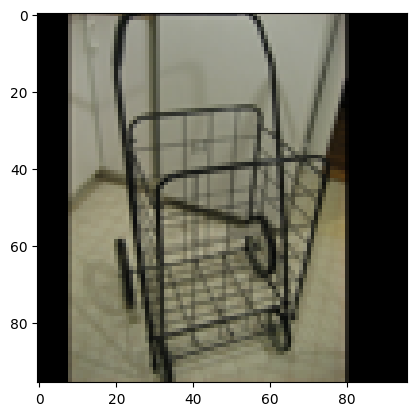

In [14]:
n = np.random.randint(0,test_images.shape[0])
plt.imshow(test_images[n])

Let us now visualize the puzzle

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puzzle(patches, ordering=None):
    """
    Plots jigsaw patches on a 96x96 canvas.

    Args:
        patches: Array of shape (9, 28, 28, 3)
        ordering: Optional array of shape (9,) or (1, 9) containing
                  the destination grid indices.
    """
    # 1. Handle ordering: if None, use [0, 1, 2... 8]
    if ordering is None:
        order = np.arange(9)
    else:
        order = np.array(ordering).flatten()

    # 2. Setup canvas (96x96x3)
    # Use 1.0 for float images (0.0-1.0) or 255 for uint8 images
    if patches.dtype == np.uint8:
        canvas = np.full((96, 96, 3), 255, dtype=np.uint8)
    else:
        canvas = np.ones((96, 96, 3), dtype=np.float32)

    cell_dim = 32
    patch_dim = 28
    margin = (cell_dim - patch_dim) // 2

    # 3. Place patches
    for i in range(9):
        # Determine destination grid position
        grid_pos = order[i]

        row = grid_pos // 3
        col = grid_pos % 3

        # Calculate canvas pixel coordinates
        y_start = (row * cell_dim) + margin
        y_end = y_start + patch_dim
        x_start = (col * cell_dim) + margin
        x_end = x_start + patch_dim

        # Insert patch i into its grid_pos
        canvas[y_start:y_end, x_start:x_end] = patches[i]

    # 4. Display
    return canvas


In [16]:
a,b = test_generator.__getitem__(1)

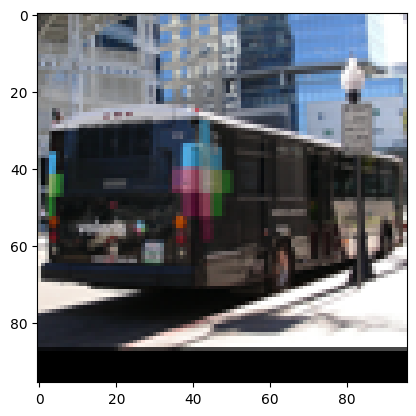

In [17]:
plt.imshow(b[4])

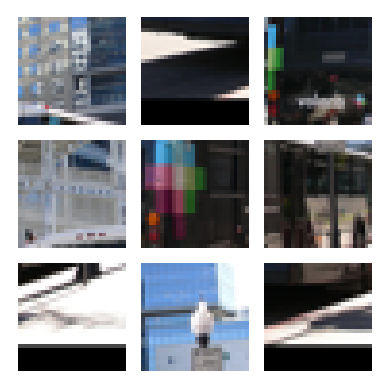

In [18]:
plt.imshow(plot_puzzle(a[4], ordering=None))
plt.axis('off')
plt.show()

# The problem

Your task is to reconstruct the source (96,96) image from the set of 9 scambled patches of dimension (28,28) each.

**The metric used to measure the quality of the reconstruction must be Mean Absolute Error (MAE).**

Compute MAE over the test set, and also return the standard deviation.


As an indicative baseline, let us compute the MAE relative to the mean patches.

In [19]:
def mean_patch_image(patches):
    #input (B,9,28,28,3)
    B = tf.shape(patches)[0] # Corrected: Use batch size from patches input
    # Mean patch
    mean_patch = tf.reduce_mean(patches, axis=1)  # (B, 28, 28, 3)
    # Replicate 9 times
    mean_patches = tf.repeat(
        mean_patch[:, None, :, :, :],
        repeats=9,
        axis=1
    )
    # Reassemble into 96x96 image

    out = tf.reshape(mean_patches, (B, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (B, 84, 84, 3))
    out = tf.image.resize(out, (96, 96))
    return out

In [20]:
#compute MAE for mean_patch_image using the test_generator
mae = tf.keras.metrics.MeanAbsoluteError()
mae_values = []
for i in range(len(test_generator)):
    a,b = test_generator.__getitem__(i)
    pred = mean_patch_image(a)
    mae_values.append(mae(pred,b))

baseline_mae_mean = tf.reduce_mean(mae_values).numpy()
baseline_mae_std = tf.math.reduce_std(mae_values).numpy()
print(f"Baseline MAE: {baseline_mae_mean:.4f} ± {baseline_mae_std:.4f}")

Baseline MAE: 0.1819 ± 0.0009


### Custom logger

In [21]:
class CustomEvaluationLogger(keras.callbacks.Callback):
    def __init__(self, test_generator):
        super().__init__()
        self.test_generator = test_generator
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_mae = logs.get('loss')
        val_mae = logs.get('val_loss')

        print(f"\nEvaluating Test Set at the end of Epoch {epoch + 1}...")
        test_mae = self.model.evaluate(self.test_generator, verbose=0)

        print(f"Epoch {epoch + 1} -> Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | Test MAE: {test_mae:.4f}")

        wandb.log({
            "Train Set MAE": train_mae,
            "Validation Set MAE": val_mae,
            "Test Set MAE": test_mae,
        })

### New generator to combine val and traind for last training epoch

In [22]:
class CombinedGenerator(keras.utils.PyDataset):
    def __init__(self, gen1, gen2, **kwargs):
        super().__init__(**kwargs)
        self.gen1 = gen1
        self.gen2 = gen2

    def __len__(self):
        return len(self.gen1) + len(self.gen2)

    def __getitem__(self, idx):
        # If the index is within the first generator, return from there
        if idx < len(self.gen1):
            return self.gen1[idx]
        # Otherwise, subtract the length of the first to get the index for the second
        else:
            return self.gen2[idx - len(self.gen1)]

    def on_epoch_end(self):
        self.gen1.on_epoch_end()
        self.gen2.on_epoch_end()

## Define the model layers

### Assembly layer

In [23]:
@keras.utils.register_keras_serializable()
class SlotPositionEmbedding(layers.Layer):
    def __init__(self, num_slots, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_slots = num_slots
        self.embed_dim = embed_dim
        self.embedding = layers.Embedding(num_slots, embed_dim)

    def call(self, inputs):
        positions = tf.range(tf.shape(inputs)[1])
        position_embeddings = self.embedding(positions)
        return inputs + tf.expand_dims(position_embeddings, axis=0)

    def get_config(self):
        config = super().get_config()
        config.update({"num_slots": self.num_slots, "embed_dim": self.embed_dim})
        return config


@keras.utils.register_keras_serializable()
class SinkhornPlacement(layers.Layer):
    def __init__(
        self,
        temperature=0.7,
        iterations=20,
        entropy_weight=0.003,
        balance_weight=0.02,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.temperature = temperature
        self.iterations = iterations
        self.entropy_weight = entropy_weight
        self.balance_weight = balance_weight

    def call(self, logits):
        log_probs = logits / self.temperature

        for _ in range(self.iterations):
            log_probs = log_probs - tf.reduce_logsumexp(log_probs, axis=-1, keepdims=True)
            log_probs = log_probs - tf.reduce_logsumexp(log_probs, axis=-2, keepdims=True)

        probs = tf.exp(log_probs)
        row_sums = tf.reduce_sum(probs, axis=-1)
        col_sums = tf.reduce_sum(probs, axis=-2)
        balance_loss = tf.reduce_mean(tf.square(row_sums - 1.0)) + tf.reduce_mean(tf.square(col_sums - 1.0))
        entropy = -tf.reduce_mean(tf.reduce_sum(probs * tf.math.log(probs + 1e-8), axis=-1))

        self.add_loss(self.balance_weight * balance_loss + self.entropy_weight * entropy)
        return probs

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "temperature": self.temperature,
                "iterations": self.iterations,
                "entropy_weight": self.entropy_weight,
                "balance_weight": self.balance_weight,
            }
        )
        return config


@keras.utils.register_keras_serializable()
class SoftPatchPlacement(layers.Layer):
    def __init__(self, image_size=96, patch_size=28, cell_size=32, margin=2, **kwargs):
        super().__init__(**kwargs)
        self.image_size = image_size
        self.patch_size = patch_size
        self.cell_size = cell_size
        self.margin = margin

    def call(self, inputs):
        patches, placement_probs = inputs
        patches = tf.cast(patches, placement_probs.dtype)
        patch_masks = tf.ones_like(patches[..., :1])

        placed_images = []
        placed_masks = []

        for pos in range(9):
            row = pos // 3
            col = pos % 3
            top = row * self.cell_size + self.margin
            left = col * self.cell_size + self.margin
            bottom = self.image_size - top - self.patch_size
            right = self.image_size - left - self.patch_size
            paddings = [[0, 0], [0, 0], [top, bottom], [left, right], [0, 0]]

            padded_patches = tf.pad(patches, paddings)
            padded_masks = tf.pad(patch_masks, paddings)
            weights = tf.reshape(placement_probs[:, :, pos], [-1, 9, 1, 1, 1])

            placed_images.append(tf.reduce_sum(padded_patches * weights, axis=1))
            placed_masks.append(tf.reduce_sum(padded_masks * weights, axis=1))

        canvas = tf.add_n(placed_images)
        mask = tf.clip_by_value(tf.add_n(placed_masks), 0.0, 1.0)
        return tf.concat([canvas, mask], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "image_size": self.image_size,
                "patch_size": self.patch_size,
                "cell_size": self.cell_size,
                "margin": self.margin,
            }
        )
        return config


### Base model

In [29]:
class JigsawSolver:
    def __init__(self, cfg):
        self.cfg = cfg
        self.model = self._build_network()

    def _transformer_block(self, x, name):
        attn_input = layers.LayerNormalization(name=f"{name}_attn_norm")(x)
        attn_output = layers.MultiHeadAttention(
            num_heads=self.cfg["num_heads"],
            key_dim=self.cfg["key_dim"],
            dropout=self.cfg["dropout"],
            name=f"{name}_attention",
        )(attn_input, attn_input)
        x = layers.Add(name=f"{name}_attn_skip")([x, attn_output])

        mlp_input = layers.LayerNormalization(name=f"{name}_mlp_norm")(x)
        mlp_output = layers.Dense(self.cfg["mlp_dim"], activation="gelu", name=f"{name}_mlp_in")(mlp_input)
        mlp_output = layers.Dropout(self.cfg["dropout"], name=f"{name}_mlp_dropout")(mlp_output)
        mlp_output = layers.Dense(x.shape[-1], name=f"{name}_mlp_out")(mlp_output)
        return layers.Add(name=f"{name}_mlp_skip")([x, mlp_output])

    def _residual_block(self, x, filters, name):
        shortcut = x
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv1")(x)
        x = layers.BatchNormalization(name=f"{name}_bn1")(x)
        x = layers.Activation("relu", name=f"{name}_relu1")(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv2")(x)
        x = layers.BatchNormalization(name=f"{name}_bn2")(x)
        x = layers.Add(name=f"{name}_skip")([shortcut, x])
        return layers.Activation("relu", name=f"{name}_relu2")(x)

    def _build_network(self):
        inputs = keras.Input(shape=(9, self.cfg["patch_size"], self.cfg["patch_size"], 3), name="shuffled_patches")

        # 1. Feature Extraction
        patch_encoder = keras.Sequential(
            [
                keras.Input(shape=(self.cfg["patch_size"], self.cfg["patch_size"], 3)),
                layers.Conv2D(32, 3, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(64, 3, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(64, 3, strides=2, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.Conv2D(128, 3, padding="same", use_bias=False),
                layers.BatchNormalization(),
                layers.Activation("relu"),
                layers.GlobalAveragePooling2D(),
                layers.Dense(self.cfg["embed_dim"], activation="relu"),
            ],
            name="patch_encoder",
        )

        tokens = layers.TimeDistributed(patch_encoder, name="encode_each_patch")(inputs)
        tokens = SlotPositionEmbedding(9, self.cfg["embed_dim"], name="input_slot_embedding")(tokens)

        for block_idx in range(3):
            tokens = self._transformer_block(tokens, name=f"patch_transformer_{block_idx + 1}")

        tokens = layers.LayerNormalization(name="patch_tokens_norm")(tokens)

        # 2. Sinkhorn Assignment
        placement_logits = layers.Dense(9, name="placement_logits")(tokens)
        placement_probs = SinkhornPlacement(
            temperature=self.cfg["sinkhorn_temp"],
            iterations=self.cfg["sinkhorn_iters"],
            entropy_weight=self.cfg["sinkhorn_entropy_weight"],
            balance_weight=self.cfg["sinkhorn_balance_weight"],
            name="placement_probs",
        )(placement_logits)

        # 3. Differentiable Canvas Assembly
        placed = SoftPatchPlacement(
            image_size=self.cfg["image_size"],
            patch_size=self.cfg["patch_size"],
            cell_size=self.cfg["cell_size"],
            margin=self.cfg["margin"],
            name="soft_patch_placement"
        )([inputs, placement_probs])

        canvas_rgb = layers.Lambda(lambda t: t[..., :3], name="placed_canvas_rgb")(placed)
        canvas_mask = layers.Lambda(lambda t: t[..., 3:4], name="placed_canvas_mask")(placed)

        # 4. Refinement Network (U-Net style)
        x = layers.Conv2D(64, 3, padding="same", use_bias=False, name="refine_in_conv")(placed)
        x = layers.BatchNormalization(name="refine_in_bn")(x)
        x = layers.Activation("relu", name="refine_in_relu")(x)
        x = self._residual_block(x, 64, "refine_96_res1")
        skip_96 = x

        x = layers.Conv2D(96, 3, strides=2, padding="same", use_bias=False, name="refine_down_48_conv")(x)
        x = layers.BatchNormalization(name="refine_down_48_bn")(x)
        x = layers.Activation("relu", name="refine_down_48_relu")(x)
        x = self._residual_block(x, 96, "refine_48_res1")
        skip_48 = x

        x = layers.Conv2D(128, 3, strides=2, padding="same", use_bias=False, name="refine_down_24_conv")(x)
        x = layers.BatchNormalization(name="refine_down_24_bn")(x)
        x = layers.Activation("relu", name="refine_down_24_relu")(x)
        x = self._residual_block(x, 128, "refine_24_res1")
        x = self._residual_block(x, 128, "refine_24_res2")

        x = layers.UpSampling2D(name="refine_up_48")(x)
        x = layers.Conv2D(96, 3, padding="same", use_bias=False, name="refine_up_48_conv")(x)
        x = layers.BatchNormalization(name="refine_up_48_bn")(x)
        x = layers.Activation("relu", name="refine_up_48_relu")(x)
        x = layers.Concatenate(name="refine_skip_48")([x, skip_48])
        x = layers.Conv2D(96, 3, padding="same", use_bias=False, name="refine_merge_48_conv")(x)
        x = layers.BatchNormalization(name="refine_merge_48_bn")(x)
        x = layers.Activation("relu", name="refine_merge_48_relu")(x)
        x = self._residual_block(x, 96, "refine_48_res2")

        x = layers.UpSampling2D(name="refine_up_96")(x)
        x = layers.Conv2D(64, 3, padding="same", use_bias=False, name="refine_up_96_conv")(x)
        x = layers.BatchNormalization(name="refine_up_96_bn")(x)
        x = layers.Activation("relu", name="refine_up_96_relu")(x)
        x = layers.Concatenate(name="refine_skip_96")([x, skip_96])
        x = layers.Conv2D(64, 3, padding="same", use_bias=False, name="refine_merge_96_conv")(x)
        x = layers.BatchNormalization(name="refine_merge_96_bn")(x)
        x = layers.Activation("relu", name="refine_merge_96_relu")(x)
        x = self._residual_block(x, 64, "refine_96_res2")

        generated = layers.Conv2D(3, 3, padding="same", activation="sigmoid", name="generated_image")(x)

        # 5. Final Output Blend
        reconstruction = layers.Lambda(
            lambda values: values[2] * (0.98 * values[0] + 0.02 * values[1]) + (1.0 - values[2]) * values[1],
            name="reconstruction",
        )([canvas_rgb, generated, canvas_mask])

        return keras.Model(inputs=inputs, outputs=reconstruction, name="jigsaw_solver_network")

    def print_parameter_count(self,printable=True):
        trainable_params = int(sum(np.prod(weight.shape) for weight in self.model.trainable_weights))
        total_params = self.model.count_params()
        if printable:
            print("Total parameters:", f"{total_params:,}")
            print("Trainable parameters:", f"{trainable_params:,}")
        return total_params, trainable_params

    def summary(self):
        self.model.summary()

    def load_weights(self, path):
        if os.path.exists(path):
            print(f"Loading weights from {path}...")
            self.model.load_weights(path)
        else:
            print(f"No checkpoint found at {path}. Starting training from scratch.")

    def _get_loss_function(self):
        def image_gradient_mae(y_true, y_pred):
            true_dy, true_dx = tf.image.image_gradients(y_true)
            pred_dy, pred_dx = tf.image.image_gradients(y_pred)
            dy_mae = tf.reduce_mean(tf.abs(true_dy - pred_dy))
            dx_mae = tf.reduce_mean(tf.abs(true_dx - pred_dx))
            return 0.5 * (dy_mae + dx_mae)

        def edge_aware_mae(y_true, y_pred):
            pixel_mae = tf.reduce_mean(tf.abs(y_true - y_pred))
            return pixel_mae + self.cfg["edge_loss_weight"] * image_gradient_mae(y_true, y_pred)

        return edge_aware_mae if self.cfg["use_edge_aware_loss"] else "mae"

    def fit(self, train_generator, val_generator, ):
        if self.cfg["use_wandb"]:
            wandb.init(
                project=self.cfg["wandb_project"],
                name=self.cfg["wandb_run_name"],
                config=self.cfg,
            )
            callbacks = [WandbMetricsLogger(log_freq="epoch"), CustomEvaluationLogger(test_generator)]
        else:
            callbacks = []
        training_loss = self._get_loss_function()
        monitor_metric = "val_mae"

        self.model.compile(
          optimizer=keras.optimizers.AdamW(learning_rate=self.cfg["lr"],weight_decay=self.cfg["weight_decay"]),
            loss=training_loss,
            metrics=[
                keras.metrics.MeanAbsoluteError(name="mae"),
                keras.metrics.MeanSquaredError(name="mse"),
            ],
        )


        best_weights_path = os.path.join(self.cfg["output_dir"], self.cfg["best_weights_filename"])
        final_weights_path = os.path.join(self.cfg["output_dir"], self.cfg["final_weights_filename"])

        callbacks = callbacks + [
            keras.callbacks.ModelCheckpoint(
                filepath=best_weights_path,
                monitor=monitor_metric,
                save_best_only=True,
                save_weights_only=True,
                verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor=monitor_metric,
                factor=self.cfg["lr_factor"],
                patience=self.cfg["reduce_lr_patience"],
                min_lr=self.cfg["min_lr"],
                verbose=1,
            ),
            keras.callbacks.EarlyStopping(
                monitor=monitor_metric,
                patience=self.cfg["early_stopping_patience"],
                verbose=1,
                restore_best_weights=True,
            ),
        ]

        history = self.model.fit(
            train_generator,
            validation_data=val_generator,
            epochs=self.cfg["epochs"],
            callbacks=callbacks,
        )


        if self.cfg["use_wandb"]:
            wandb.finish()
        # combine validation and train data to final run
        combined_gen = CombinedGenerator(train_generator, val_generator)
        if self.cfg["use_wandb"]:
            wandb.init(
                project=self.cfg["wandb_project"],
                name=self.cfg["wandb_run_name"],
                config=self.cfg,
            )
            callbacks = [WandbMetricsLogger(log_freq="epoch"), CustomEvaluationLogger(test_generator)]
        else:
            callbacks = []
        self.model.fit(
            combined_gen,
            epochs=1,
            callbacks=callbacks,
        )
        self.model.save_weights(final_weights_path)
        print("Saved final weights to:", final_weights_path)

        return history

## Train

In [ ]:
def download_gdown(gdown_id):
  print(f"Downloading weights to {os.path.join(cfg["output_dir"], cfg["gdown_output_path"])}...")
  gdown.download(f'https://drive.google.com/uc?id={gdown_id}', cfg["gdown_output_path"], quiet=False)

# Optional: Verify it downloaded successfully
  if os.path.exists(cfg["gdown_output_path"]):
      print("Download complete! You can now load your weights.")
  else:
      print("Download failed.")

In [30]:
solver = JigsawSolver(cfg)
solver.summary()

if cfg["load_weights_local"]:
    solver.load_weights(os.path.join(cfg["output_dir"], cfg["best_weights_filename"]))
elif cfg["load_weights_gdown"]:
    download_gdown(cfg["gdown_id"])
    solver.load_weights(os.path.join(cfg["output_dir"], cfg["gdown_output_path"]))
else:
    print("Start Training without weights")
    history = solver.fit(train_generator, val_generator)


Model: "jigsaw_solver_network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ shuffled_patches    │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encode_each_patch   │ (None, 9, 192)    │    165,152 │ shuffled_patches… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_slot_embeddi… │ (None, 9, 192)    │      1,728 │ encode_each_patc… │
│ (SlotPositionEmbed… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ input_slot_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ input_slot_embed… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │     73,920 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme

 Total params: 2,711,596 (10.34 MB)

 Trainable params: 2,707,436 (10.33 MB)

 Non-trainable params: 4,160 (16.25 KB)

Start Training without weights
Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1380 - mae: 0.1343 - mse: 0.0376
Epoch 1: val_mae improved from None to 0.10814, saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_best_adamw.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_best_adamw.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 201s 91ms/step - loss: 0.1260 - mae: 0.1230 - mse: 0.0344 - val_loss: 0.1105 - val_mae: 0.1081 - val_mse: 0.0305 - learning_rate: 0.0010
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1086 - mae: 0.1064 - mse: 0.0296
Epoch 2: val_mae improved from 0.10814 to 0.09770, saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_best_adamw.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/jigsaw_outputs/jigsaw_best_adamw.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 93s 74ms/step - loss: 0.1060 - mae: 0.1039 - mse: 0.0288 - val_loss: 0.0997 - val_mae: 0.0977 - val_mse: 

In [31]:
def evaluate_and_get_metrics(solver, generator):
    """
    Evaluates the JigsawSolver on a given dataset generator.

    Args:
        solver: The JigsawSolver instance (or the compiled keras model directly).
        generator: A tf.keras.utils.Sequence yielding (x_batch, y_true_batch).

    Returns:
        mae_mean: The overall Mean Absolute Error across all batches.
        mae_std: The standard deviation of the MAE across batches.
    """
    # Extract the underlying Keras model if the JigsawSolver instance was passed
    model = solver.model if hasattr(solver, 'model') else solver

    mae_values = []

    for i in range(len(generator)):
        x_batch, y_true_img = generator[i]

        # The JigsawSolver directly outputs the blended reconstruction
        # training=False ensures layers like Dropout and BatchNorm act in inference mode
        y_pred_img = model(x_batch, training=False)

        # Calculate MAE specifically for the current batch
        batch_mae = tf.reduce_mean(tf.abs(y_true_img - y_pred_img)).numpy()
        mae_values.append(batch_mae)

    # Compute overall mean and standard deviation across independent batches
    mae_mean = np.mean(mae_values)
    mae_std = np.std(mae_values)

    return mae_mean, mae_std

In [32]:
mae_mean, std = evaluate_and_get_metrics(solver, test_generator)
print(f"Test MAE over all test batches: {mae_mean}")
print(f"Test std: {std}")

Test MAE over all test batches: 0.07400824874639511
Test std: 0.0077487146481871605


### Visualize results

In [33]:


def visualize_random_predictions(solver, generator, num_samples=3):
    """
    Visualizes the input patches, ground truth, network reconstruction,
    and absolute error for random samples in a batch.
    """
    # Extract the Keras model just in case the class instance was passed
    model = solver.model if hasattr(solver, 'model') else solver

    # Pick a random batch
    batch_idx = random.randint(0, len(generator) - 1)
    X_batch, Y_batch = generator[batch_idx]

    # Predict directly using the network
    # training=False ensures deterministic behavior for dropout/batchnorm layers
    preds = model(X_batch, training=False).numpy()

    # Pick random indices within the batch
    actual_batch_size = len(X_batch)
    sample_indices = random.sample(range(actual_batch_size), min(num_samples, actual_batch_size))

    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5 * num_samples))

    # Safely handle the 1D axes array case if num_samples is 1
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(sample_indices):
        orig_img = Y_batch[idx]
        pred_img = preds[idx]
        scrambled_patches = X_batch[idx]  # Shape: (9, 28, 28, 3)

        # Assemble scrambled patches into a grid for visualization
        # (Assuming plot_puzzle is defined elsewhere in your code)
        scrambled_grid = plot_puzzle(scrambled_patches, ordering=None)

        # Calculate Absolute Difference and MAE
        abs_diff = np.abs(orig_img - pred_img)
        mae = np.mean(abs_diff)

        # Column 0: Scrambled Input
        axes[i][0].imshow(scrambled_grid)
        axes[i][0].set_title("Scrambled Input")
        axes[i][0].axis('off')

        # Column 1: Original Image
        axes[i][1].imshow(orig_img)
        axes[i][1].set_title("Original Image")
        axes[i][1].axis('off')

        # Column 2: Reconstructed Output
        axes[i][2].imshow(pred_img)
        axes[i][2].set_title(f"Reconstructed (MAE: {mae:.4f})")
        axes[i][2].axis('off')

        # Column 3: Absolute Error
        axes[i][3].imshow(np.clip(abs_diff, 0, 1))
        axes[i][3].set_title("Absolute Error")
        axes[i][3].axis('off')

    plt.tight_layout()
    plt.show()

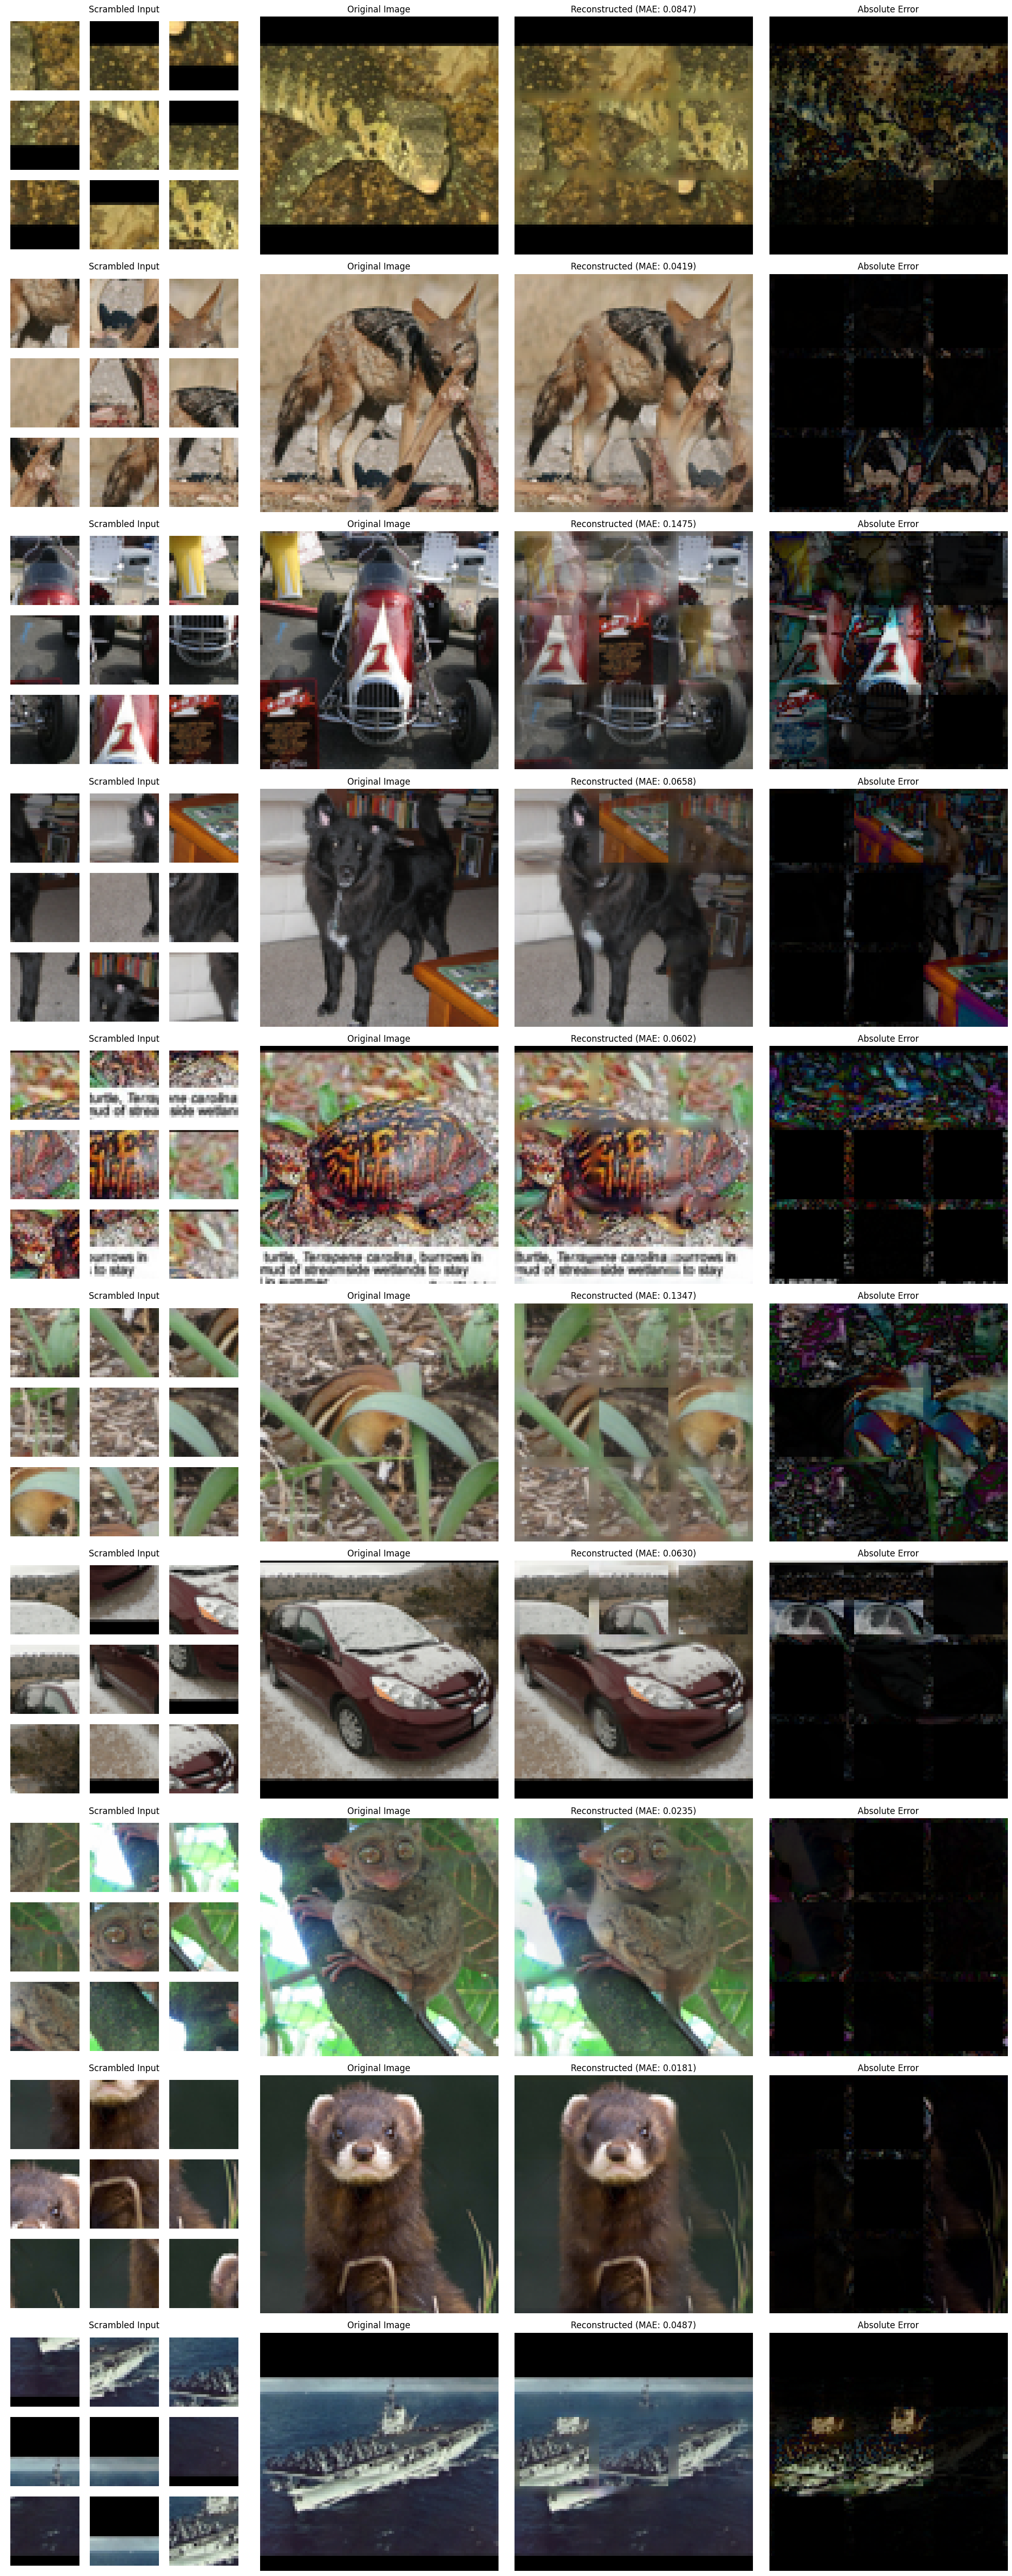

In [34]:
visualize_random_predictions(solver, test_generator, num_samples=10)

### plot losses curves

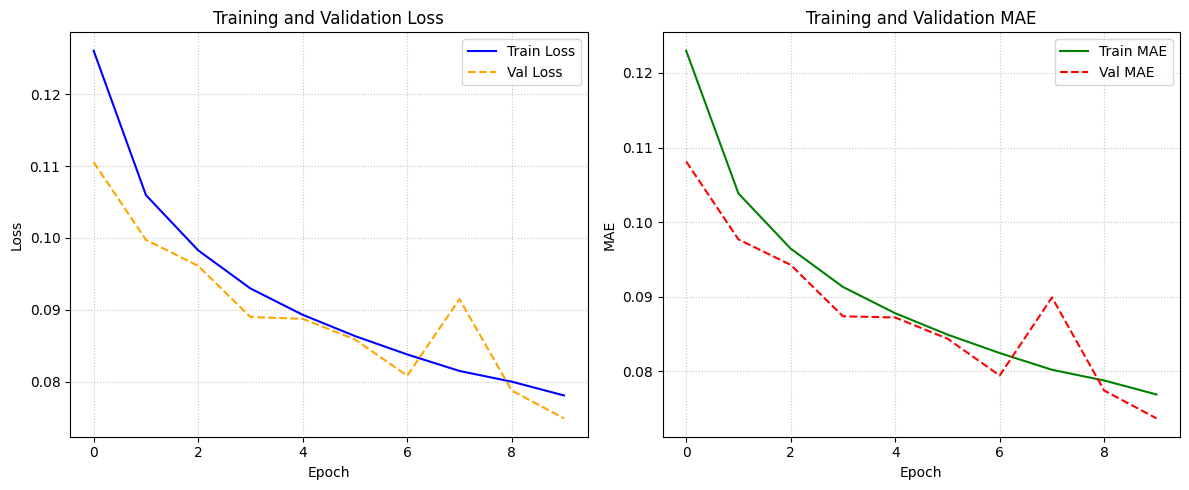

In [39]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Extract the dictionary (handles both Keras History objects and raw dictionaries)
    hist_data = history.history if hasattr(history, 'history') else history

    plt.figure(figsize=(12, 5))

    # 1. Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(hist_data['loss'], label='Train Loss', color='blue')
    if 'val_loss' in hist_data:
        plt.plot(hist_data['val_loss'], label='Val Loss', color='orange', linestyle='--')

    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()

    # 2. Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(hist_data['mae'], label='Train MAE', color='green')
    if 'val_mae' in hist_data:
        plt.plot(hist_data['val_mae'], label='Val MAE', color='red', linestyle='--')

    plt.title('Training and Validation MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [36]:
def pretty_print_results():
    # total params
    total_params, trainable_params = solver.print_parameter_count(printable=False)
    # print total params in millions and trainable params in millions in pretty format
    print("\n--- Final Results ---")
    print("-" * 20)
    print("="*10 + " Model Summary " + "="*10)
    print(f"Total parameters: {total_params / 1e6:.2f}M")
    print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")
    # Baseline MAE
    print("-" * 20)
    print("="*10 + " Baseline Comparison " + "="*10)
    print(f"Baseline MAE (): {baseline_mae_mean:.4f} ± {baseline_mae_std:.4f}")
    # Final Test MAE
    print(f"Final Test MAE: {mae_mean:.4f} ± {std:.4f}")
pretty_print_results()


--- Final Results ---
--------------------
========== Model Summary ==========
Total parameters: 2.71M
Trainable parameters: 2.71M
--------------------
========== Baseline Comparison ==========
Baseline MAE (): 0.1819 ± 0.0009
Final Test MAE: 0.0740 ± 0.0077


# Additional Constraints

* The solution must rely entirely on neural networks and must not contain non-neural algorithmic components. A pipeline of neural networks is allowed.
* Pretrained models are not permitted.
* The total number of trainable parameters must remain below 6 million. The number of parameters of the proposed solution must be reported explicitly.
* The model weights must be made available for download via gdown. Please verify that the provided link works correctly and that the weights can be loaded successfully.
* The solution must be implemented in Keras and must run on Google Colab. Submissions containing notebook execution errors will be penalized.
* The submission must be a single, well documented notebook file. Tar files will be rejected.



